In [4]:
import torch
import os
import sys
from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from datetime import datetime

ModuleNotFoundError: No module named 'torch'

In [10]:
import os
import sys

os.path.abspath(os.path.join(os.getcwd(), "../.."))

'c:\\Users\\Tushar\\OneDrive\\Desktop\\Dog_Cat_Person_CNN_Classification Model\\gradio-app-1'

In [11]:
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..")))
from config import TRAINING_DIR, TESTING_DIR, CORE_OP_FOLDER

In [ ]:
image_dir = TRAINING_DIR
for label, class_dir in enumerate(os.listdir(image_dir)):
    print(label, class_dir)

0 Cat
1 Dog
2 person


In [3]:
class ImageDataset(Dataset):
    def __init__(self, image_dir, transform = None):
        self.image_dir = image_dir
        self.image_paths = []
        self.labels = []
        self.class_name = {}
        self.transform = transform

        for label, class_dir in enumerate(os.listdir(image_dir)):
            self.class_name[label] = class_dir
            class_path = os.path.join(image_dir, class_dir)
            for img_name in os.listdir(class_path):
                self.image_paths.append(os.path.join(class_path, img_name))
                self.labels.append(label)


    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image =Image.open(img_path).convert("RGB")
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

In [4]:
transform = transforms.Compose(
    [
    transforms.Resize((128, 128)),    # Reducing quality to speed up training
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
    
    ]
)

In [ ]:
train_image_dir = TRAINING_DIR
test_image_dir = TESTING_DIR

train_image_dataset = ImageDataset(image_dir=train_image_dir, transform=transform)
test_image_dataset = ImageDataset(image_dir=test_image_dir, transform=transform)

In [6]:
train_image_loader = DataLoader(dataset=train_image_dataset, batch_size=32, shuffle=True)
test_image_loader = DataLoader(dataset=test_image_dataset, batch_size=32, shuffle=True)

In [7]:
# for images, labels in train_image_loader:
#     print(images.shape, labels.shape)

In [8]:
import matplotlib.pyplot as plt
import numpy as np 

In [9]:
print(train_image_dataset.class_name)
print(test_image_dataset.class_name)

{0: 'Cat', 1: 'Dog', 2: 'person'}
{0: 'Cat', 1: 'Dog', 2: 'person'}


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


torch.Size([32, 3, 128, 128]) torch.Size([32])
Cat
(128, 128, 3)
0


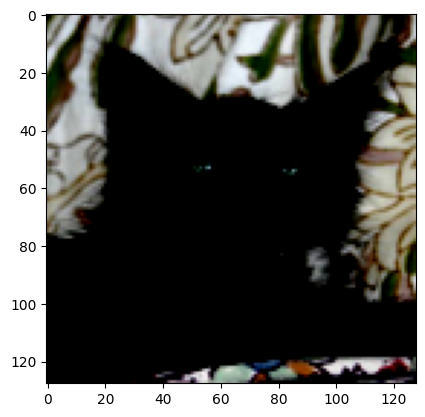

In [10]:
for images, labels in train_image_loader:
    print(images.shape, labels.shape)
    img = images[0].numpy()
    label  = labels[0].item()
    print(train_image_dataset.class_name[label])
    img = np.transpose(img, (1, 2, 0 ))

    print(img.shape)
    print(label)
    plt.imshow(img, vmin=0, vmax=255)
    plt.show()
    break

# Custom CNN Architecture

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
import cv2

In [12]:
class CustomCnnModel(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(CustomCnnModel, self).__init__()
        self.input_dim = input_dim
        self.num_classes = num_classes

        self.conv_layers = nn.Sequential(
            #C1
            nn.Conv2d(3, 32, 3, 1, 1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            #C2
            nn.Conv2d(32, 64, 3, 1, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            #C3
            nn.Conv2d(64, 128, 3, 1, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            #C4
            nn.Conv2d(128, 256, 3, 1, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self._to_linear= None
        self._get_conv_output(self.input_dim)

        self.fc_layers =nn.Sequential(
            nn.Linear(self._to_linear, 512),
            nn.ReLU(),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, self.num_classes)
        )

    def _get_conv_output(self, input_dim = 128):
        with torch.no_grad():
            dummy_input = torch.zeros(1, 3, input_dim, input_dim)
            output = self.conv_layers(dummy_input)
            self._to_linear = output.view(1, -1).size(1)
            

    def forward(self, X):
        X = self.conv_layers(X)
        X = X.view(X.size(0), -1)
        X = self.fc_layers(X)
        return X 

In [13]:
# Initialize the Model
device = torch.device('cuda' if torch.cuda.is_available() else False)
model = CustomCnnModel(input_dim=128, num_classes=3).to(device)

In [14]:
print(model)

CustomCnnModel(
  (conv_layers): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_sta

In [15]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)

In [16]:
# Training Loop
epochs = 50
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_image_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss+=loss.item()

    print(f"Epochs {epoch+1}/{epochs}, Loss : {running_loss/len(train_image_loader)}")



Epochs 1/50, Loss : 0.9001763779866068
Epochs 2/50, Loss : 0.592596636163561
Epochs 3/50, Loss : 0.5028503028970016
Epochs 4/50, Loss : 0.45614862677298096
Epochs 5/50, Loss : 0.4002628086428893
Epochs 6/50, Loss : 0.3773463577032089
Epochs 7/50, Loss : 0.3371673069502178
Epochs 8/50, Loss : 0.26425966847884025
Epochs 9/50, Loss : 0.2620718113685909
Epochs 10/50, Loss : 0.23059844896197318
Epochs 11/50, Loss : 0.19918575918203907
Epochs 12/50, Loss : 0.16999853816079466
Epochs 13/50, Loss : 0.1097047592856382
Epochs 14/50, Loss : 0.08430570023820588
Epochs 15/50, Loss : 0.09961986137848151
Epochs 16/50, Loss : 0.07615167805925012
Epochs 17/50, Loss : 0.06398406827969379
Epochs 18/50, Loss : 0.02527224588771596
Epochs 19/50, Loss : 0.07143162011021846
Epochs 20/50, Loss : 0.061943055130541325
Epochs 21/50, Loss : 0.05799604610932109
Epochs 22/50, Loss : 0.05331297232175865
Epochs 23/50, Loss : 0.03124718351387664
Epochs 24/50, Loss : 0.010306016900990232
Epochs 25/50, Loss : 0.015165976

In [22]:
torch.save(model.state_dict(), "cnn_model_50_epoch.pth")

In [23]:
#Evaluate the models

model.eval()
correct = 0 
total = 0

with torch.no_grad():
    for images, labels in test_image_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct+= (predicted==labels).sum().item()

print(f"Test accuracy is : {100 * correct / total:.2f}%")



Test accuracy is : 83.50%


In [ ]:
class ImageClassifier:
    def __init__(self, model_path, class_names):
        self.device = torch.device('cuda' if torch.cuda.is_available() else False)
        self.model = CustomCnnModel(input_dim=128, num_classes=3).to(self.device)
        self.model.load_state_dict(torch.load(model_path, map_location=self.device))

        self.model.eval()
        self.class_names = class_names
        self.transform = transforms.Compose(
                                        [
                                        transforms.Resize((128, 128)),    # Reducing quality to speed up training
                                        transforms.ToTensor(),
                                        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
                                        
                                        ]
                                    )
        

    def predict(self, image_path):
        image = Image.open(image_path).convert("RGB")
        input_tensor = self.transform(image).unsqueeze(0).to(self.device)

        with torch.no_grad():
            output = self.model(input_tensor)
            _, predicted = torch.max(output, 1)
                
        label = self.class_names[predicted.item()]

        output_folder = CORE_OP_FOLDER
        os.makedirs(output_folder, exist_ok=True)
        img = cv2.imread(image_path)

        h, w, _ = img.shape
        font_scale = w / 500 
        thickness = max(2, w // 200) 
        text_size = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, font_scale, thickness)[0]
        text_x = (w - text_size[0]) // 2
        text_y = text_size[1] + 25

        cv2.putText(img, label, (text_x+2, text_y+2), cv2.FONT_HERSHEY_SIMPLEX, font_scale, (0,0,0), thickness+1)
        cv2.putText(img, label, (text_x, text_y), cv2.FONT_HERSHEY_SIMPLEX, font_scale, (255, 255, 0), thickness)

        cv2.imwrite(f"{output_folder}/output_image_{datetime.now().strftime('%Y%m%d_%H%M%S%f')}.jpg", img)

        return label
                                            